<a href="https://colab.research.google.com/github/Saibhossain/Interview-agent/blob/main/Simple_prototype.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AI Interview Simulator

# setup

In [1]:
!pip install langgraph langchain-core

# import


In [18]:
from typing import TypedDict, List, Annotated
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage, HumanMessage, BaseMessage
from langgraph.checkpoint.memory import MemorySaver

In [19]:
# state definition

class InterviewState(TypedDict):
  messages: Annotated[List[BaseMessage], add_messages]
  cv_text: str
  interview_plan : List[str]
  follow_up_count :int
  current_intent : str
  need_follow_up : bool
  evaluation_report: List[dict]

## Function of nodes

In [20]:
def parse_cv_node(state: InterviewState):
    print("\n[NODE: parse_cv] Extracting skills from CV...")
    # Replace with LLM CV extraction
    return {"cv_text": state.get("cv_text", "Python Developer CV")}

def plan_interview_node(state: InterviewState):
    print("[NODE: plan_interview] Generating interview agenda...")
    # Replace with LLM planning based on CV
    plan = ["Introduction", "Python Generators", "System Design"]
    return {"interview_plan": plan, "evaluation_report": []}

def manager_node(state: InterviewState):
    print("\n[NODE: manager] Managing interview flow...")
    plan = state.get("interview_plan", [])

    if not plan:
        return {"current_topic": None} # Nothing left to ask

    next_topic = plan[0]
    remaining_plan = plan[1:]
    print(f"--> Transitioning to topic: {next_topic}")

    return {
        "current_topic": next_topic,
        "interview_plan": remaining_plan,
        "follow_up_count": 0 # Reset follow-ups for the new topic
    }

def ask_main_question_node(state: InterviewState):
    topic = state.get("current_topic")
    print(f"\n[NODE: ask_main_question] Asking about: {topic}")
    # Replace with LLM generating a question based on the topic
    question = f"Can you tell me about your experience with {topic}?"
    return {"messages": [AIMessage(content=question)]}

def analyze_input_node(state: InterviewState):
    print("\n[NODE: analyze_input] Analyzing candidate's message...")
    last_message = state["messages"][-1].content.lower()

    # Replace with LLM intent detection (e.g., does the user need help or did they answer?)
    if "?" in last_message or "don't understand" in last_message:
        intent = "clarify"
    else:
        intent = "evaluate"

    print(f"--> Detected Intent: {intent}")
    return {"current_intent": intent}

def handle_clarification_node(state: InterviewState):
    print("\n[NODE: handle_clarification] Answering candidate's question...")
    # Replace with LLM answering the candidate's clarifying question
    response = "Good question! Let me clarify: I am looking for a brief overview. What do you think?"
    return {"messages": [AIMessage(content=response)]}

def evaluate_answer_node(state: InterviewState):
    print("\n[NODE: evaluate_answer] Grading response...")
    last_message = state["messages"][-1].content

    # Replace with LLM evaluation (Score out of 10, deciding if follow-up is needed)
    needs_follow_up = False
    if len(last_message) < 20: # Mock logic: if answer is too short, drill down
        needs_follow_up = True

    print(f"--> Needs Follow-up? {needs_follow_up}")
    report_entry = {"topic": state["current_topic"], "score": 8, "notes": "Candidate did well."}

    return {
        "needs_follow_up": needs_follow_up,
        "evaluation_report": [report_entry] # This gets appended automatically by LangGraph if configured, but here we just pass it
    }

def ask_followup_node(state: InterviewState):
    print("\n[NODE: ask_followup] Asking a deeper question...")
    count = state.get("follow_up_count", 0)

    # Replace with LLM generating a follow-up
    question = "Could you elaborate a bit more on that specific point?"

    return {
        "messages": [AIMessage(content=question)],
        "follow_up_count": count + 1
    }

def generate_report_node(state: InterviewState):
    print("\n[NODE: generate_report] Compiling final interview report...")
    # Replace with LLM summarizing the evaluation_report
    return {"messages": [AIMessage(content="Interview complete. Thank you!")]}

## conditional stare router

In [21]:
def route_manager(state: InterviewState):
    if state.get("current_topic") is None:
        return "end_interview"
    return "next_question"

def route_candidate_intent(state: InterviewState):
    return state.get("current_intent") # Returns "evaluate" or "clarify"

def route_evaluation(state: InterviewState):
    # If the LLM says we need a follow up, AND we haven't asked too many already
    if state.get("needs_follow_up") and state.get("follow_up_count", 0) < 2:
        return "follow_up"
    return "topic_complete"


In [22]:
builder = StateGraph(InterviewState)

builder.add_node("parse_cv", parse_cv_node)
builder.add_node("plan_interview", plan_interview_node)
builder.add_node("interview_manager", manager_node)
builder.add_node("ask_main_question", ask_main_question_node)
builder.add_node("analyze_input", analyze_input_node)
builder.add_node("handle_clarification", handle_clarification_node)
builder.add_node("evaluate_answer", evaluate_answer_node)
builder.add_node("ask_followup", ask_followup_node)
builder.add_node("generate_report", generate_report_node)

builder.set_entry_point("parse_cv")
builder.add_edge("parse_cv", "plan_interview")
builder.add_edge("plan_interview", "interview_manager")

builder.add_conditional_edges(
    "interview_manager",
    route_manager,
    {"next_question": "ask_main_question", "end_interview": "generate_report"}
)

builder.add_edge("ask_main_question", "analyze_input")
builder.add_edge("ask_followup", "analyze_input")
builder.add_edge("handle_clarification", "analyze_input")

builder.add_conditional_edges(
    "analyze_input",
    route_candidate_intent,
    {"evaluate": "evaluate_answer", "clarify": "handle_clarification"}
)

builder.add_conditional_edges(
    "evaluate_answer",
    route_evaluation,
    {"follow_up": "ask_followup", "topic_complete": "interview_manager"}
)

builder.add_edge("generate_report", END)

memory = MemorySaver()
graph = builder.compile(checkpointer=memory,interrupt_before=["analyze_input"])

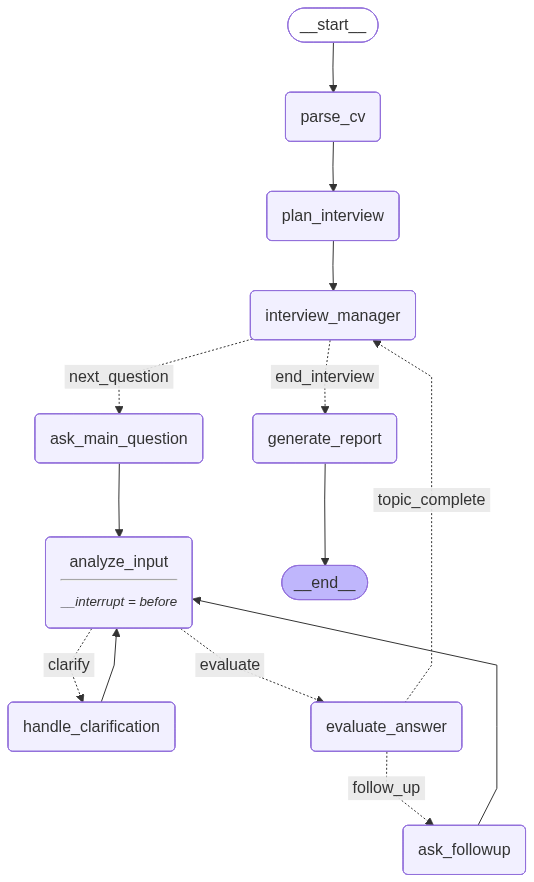

In [23]:
graph

In [27]:

thread = {"configurable": {"thread_id": "interview_1"}}
initial_state = {"cv_text"}
initial_state = {"cv_text": "Experienced Python Developer with distributed systems background."}

print("Starting Interview Simulator...")

for event in graph.stream(initial_state, thread):
    pass

while True:
  state = graph.get_state(thread)

  if not state.next:
    print("\nFinal Messages:", state.values["messages"][-1].content)
    break

  last_ai_message = state.values["messages"][-1].content
  print(f"\nAI Interviewer: {last_ai_message}")

  user_input = input("User: ")
  graph.update_state(thread, {"messages": [HumanMessage(content=user_input)]})

  for event in graph.stream(None, thread):
    pass



Starting Interview Simulator...

[NODE: parse_cv] Extracting skills from CV...
[NODE: plan_interview] Generating interview agenda...

[NODE: manager] Managing interview flow...
--> Transitioning to topic: Introduction

[NODE: ask_main_question] Asking about: Introduction

AI Interviewer: Can you tell me about your experience with Introduction?
User: it is so good , and skill sharing 

[NODE: analyze_input] Analyzing candidate's message...
--> Detected Intent: evaluate

[NODE: evaluate_answer] Grading response...
--> Needs Follow-up? False

[NODE: manager] Managing interview flow...
--> Transitioning to topic: Python Generators

[NODE: ask_main_question] Asking about: Python Generators

AI Interviewer: Can you tell me about your experience with Python Generators?
User: Python generators are a powerful and memory-efficient way to create iterators

[NODE: analyze_input] Analyzing candidate's message...
--> Detected Intent: evaluate

[NODE: evaluate_answer] Grading response...
--> Needs Fo